# Face detection fundamentals

Prepared for Shivam Singh · MathTech

## Theory
Haar detects frontal face patterns. Detection confidence and temporary track IDs are different concepts. The generated demo uses scripted boxes, so it is useful for interface tests but not accuracy claims.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.detection.opencv_detector import HaarDetector
frame = demo_frame(0)
detector = HaarDetector()
faces = detector.detect(frame)
print("Haar detections in synthetic illustration:", len(faces))
detector.close()
scripted = SyntheticDetector().detect(frame)
print("Scripted demo subjects:", len(scripted))


Haar detections in synthetic illustration: 0
Scripted demo subjects: 2


## Visualization

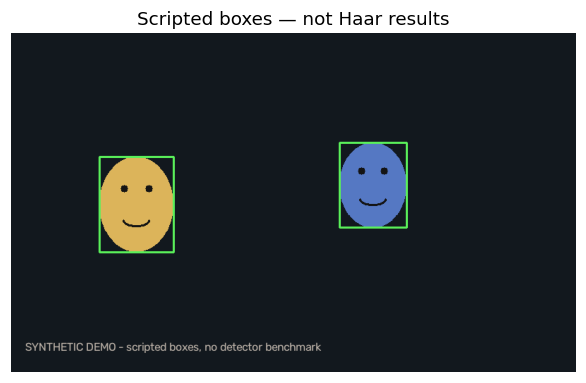

In [3]:
view = frame.copy()
for face in scripted:
    x, y, w, h = face.bbox.ints()
    cv2.rectangle(view, (x, y), (x+w, y+h), (90, 240, 90), 2)
plt.imshow(cv2.cvtColor(view, cv2.COLOR_BGR2RGB)); plt.title("Scripted boxes — not Haar results"); plt.axis("off"); plt.show()


## Experiment

In [4]:
# A true blank frame should not produce a face in the lightweight detector.
detector = HaarDetector()
blank_results = detector.detect(np.zeros((320, 320, 3), np.uint8))
assert len(blank_results) == 0
print("Blank-image regression passed")
detector.close()


Blank-image regression passed


## Observations
For a real-image experiment, load a consenting subject image with cv2.imread, then repeat HaarDetector.detect. Test scale, pose and illumination against hand-labelled boxes. Synthetic illustrations do not establish recall.

## Conclusion
Detection is an observation with uncertainty; it is not a persistent identity.